# Jigsaw Unintended Bias in Toxicity Classification

An NLP project that classifies online comments as **toxic** or **non-toxic**, built on
Google Jigsaw's Civil Comments dataset. It compares classical machine-learning baselines
(TF-IDF + Logistic Regression / LinearSVC) against an LSTM with learned word embeddings,
and tackles the dataset's heavy class imbalance along the way.


In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ishanagrawal20","key":"61b7162b0fccb919ea0ece64aed2570f"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c jigsaw-unintended-bias-in-toxicity-classification
!unzip -q jigsaw-unintended-bias-in-toxicity-classification.zip

100% 723M/723M [00:18<00:00, 40.9MB/s]



In [3]:
import pandas as pd
df = pd.read_csv("train.csv")

print("rows, columns:", df.shape)
df.head()

rows, columns: (1804874, 45)


,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59848,0.000000,"This is so cool. It's like, 'would you want yo...",0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
1,59849,0.000000,Thank you!! This would make my life a lot less...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
2,59852,0.000000,This is such an urgent design problem; kudos t...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
3,59855,0.000000,Is this something I'll be able to install on m...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
4,59856,0.893617,haha you guys are a bunch of losers.,0.021277,0.0,0.021277,0.87234,0.0,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.0,4,47


In [4]:
df["target"].describe()

,target
count,1.804874e+06
mean,1.030173e-01
std,1.970757e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.666667e-01
max,1.000000e+00


In [5]:
df["toxic"] = (df["target"] >= 0.5).astype(int)

In [6]:
df["toxic"].value_counts()

,count
toxic,
0,1660540
1,144334


In [7]:
counts = df["toxic"].value_counts()
ratio = counts[0] / counts[1]
print(f"non-toxic : toxic  =  {ratio:.1f} : 1")

non-toxic : toxic  =  11.5 : 1


In [8]:
df[df["toxic"] == 1]["comment_text"].head(3).tolist()

['haha you guys are a bunch of losers.',
 'ur a sh*tty comment.',
 'It\'s ridiculous that these guys are being called "protesters". Being armed is a threat of violence, which makes them terrorists.']

In [9]:
df[df["toxic"] == 0]["comment_text"].head(3).tolist()

["This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!",
 "Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!",
 'This is such an urgent design problem; kudos to you for taking it on. Very impressive!']

In [10]:
data = df[["comment_text", "toxic"]].copy()

data = data.sample(100000, random_state=42).reset_index(drop=True)

print(data.shape)
print(data["toxic"].value_counts())

(100000, 2)
toxic
0    92062
1     7938
Name: count, dtype: int64


In [11]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [12]:
data["clean_text"] = data["comment_text"].apply(clean_text)

data[["comment_text", "clean_text"]].head()

,comment_text,clean_text
0,What a breathe of fresh air to have someone wh...,what a breathe of fresh air to have someone wh...
1,Your jewish friends were the ones who told you...,your jewish friends were the ones who told you...
2,Possible collusion by Trump and his affiliates...,possible collusion by trump and his affiliates...
3,Exactly. We need a % of GDP spending cap at t...,exactly we need a of gdp spending cap at the f...
4,"By your own comment, even if some of them vote...",by your own comment even if some of them voted...


In [13]:
print("empty after cleaning:", (data["clean_text"].str.len() == 0).sum())

data = data[data["clean_text"].str.len() > 0].reset_index(drop=True)
print("rows now:", data.shape)

empty after cleaning: 140
rows now: (99860, 3)


In [14]:
from sklearn.model_selection import train_test_split

X = data["clean_text"]
y = data["toxic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("train size:", X_train.shape[0])
print("test size: ", X_test.shape[0])

train size: 79888
test size:  19972


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(X_train_vec.shape)

(79888, 20000)


In [16]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_vec, y_train)

print(pd.Series(y_train_bal).value_counts())

toxic
0    6350
1    6350
Name: count, dtype: int64


In [17]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

In [18]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = logreg.predict(X_test_vec)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test_vec)[:, 1]))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93     18384
           1       0.36      0.77      0.49      1588

    accuracy                           0.87     19972
   macro avg       0.67      0.83      0.71     19972
weighted avg       0.93      0.87      0.89     19972

ROC-AUC: 0.905995647978858
[[16191  2193]
 [  363  1225]]


In [19]:
from sklearn.svm import LinearSVC

svc = LinearSVC()
svc.fit(X_train_bal, y_train_bal)

y_pred_svc = svc.predict(X_test_vec)
print(classification_report(y_test, y_pred_svc))

print("ROC-AUC:", roc_auc_score(y_test, svc.decision_function(X_test_vec)))
print(confusion_matrix(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     18384
           1       0.31      0.79      0.45      1588

    accuracy                           0.85     19972
   macro avg       0.65      0.82      0.68     19972
weighted avg       0.93      0.85      0.87     19972

ROC-AUC: 0.8958337957604137
[[15625  2759]
 [  327  1261]]


In [20]:
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
except ImportError:
    from keras.preprocessing.text import Tokenizer
    from keras.utils import pad_sequences

VOCAB_SIZE = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="pre", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="pre", truncating="post")

print(X_train_pad.shape)
print(X_train_pad[0])

(79888, 200)
[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     2  1052   340     7     2
     1  7348     5    53    61 10574     4  5890    57  2256    15   297
    41    51  1202     2  4584    13   192   555  7489   896     6   444
   413   211    25    41     2  9046  1035    52   435    58     6 14269
  6707     6  4462  7090   823     4    20  1084    34  4462   239    53
     8    71     3  2033     6  5802     1  1195     4  1255     5   298
     5    19     8     2   442     5 19412     6  1898 12510    41     2
   324  1035    21     2 10016     6   487     4  3239   382   331  2781
    47    68  7760   155    22   324   246     2  1255    36  1253    22
   442     5   647   155     9   353  

In [21]:
import tensorflow as tf

EMBED_DIM = 64

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("GPU:", tf.config.list_physical_devices('GPU'))

y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

weights = compute_class_weight(class_weight="balanced",
                               classes=np.array([0, 1]),
                               y=y_train_arr)
class_weight = {0: weights[0], 1: weights[1]}
print("class weights:", class_weight)


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
class weights: {0: np.float64(0.5431749571650031), 1: np.float64(6.290393700787401)}


In [23]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(X_train_pad[0])

[    2  1052   340     7     2     1  7348     5    53    61 10574     4
  5890    57  2256    15   297    41    51  1202     2  4584    13   192
   555  7489   896     6   444   413   211    25    41     2  9046  1035
    52   435    58     6 14269  6707     6  4462  7090   823     4    20
  1084    34  4462   239    53     8    71     3  2033     6  5802     1
  1195     4  1255     5   298     5    19     8     2   442     5 19412
     6  1898 12510    41     2   324  1035    21     2 10016     6   487
     4  3239   382   331  2781    47    68  7760   155    22   324   246
     2  1255    36  1253    22   442     5   647   155     9   353   324
     7   132     6  1255   110     4  2986   669    40  4258  2971    13
  4933   442     5   647   155     9   211     2   446     5  3123  4336
     7    50  2151  3665    50     2  1068    15    96   332    35 12511
  3974     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0   

In [24]:
history = model.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    class_weight=class_weight
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.7686 - auc: 0.8148 - loss: 0.5256 - val_accuracy: 0.8880 - val_auc: 0.8964 - val_loss: 0.3489
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8770 - auc: 0.9349 - loss: 0.3238 - val_accuracy: 0.8785 - val_auc: 0.9142 - val_loss: 0.3031
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9008 - auc: 0.9639 - loss: 0.2390 - val_accuracy: 0.8649 - val_auc: 0.9022 - val_loss: 0.3382
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9250 - auc: 0.9789 - loss: 0.1749 - val_accuracy: 0.9002 - val_auc: 0.8898 - val_loss: 0.2586
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9308 - auc: 0.9815 - loss: 0.1571 - val_accuracy: 0.8686 - val_auc: 0.8806 - val_loss: 0.3461


In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9499 - auc: 0.9894 - loss: 0.1137 - val_accuracy: 0.8881 - val_auc: 0.8739 - val_loss: 0.3479
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9427 - auc: 0.9877 - loss: 0.1264 - val_accuracy: 0.8956 - val_auc: 0.8752 - val_loss: 0.3485
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9664 - auc: 0.9934 - loss: 0.0796 - val_accuracy: 0.9128 - val_auc: 0.8507 - val_loss: 0.3461
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9588 - auc: 0.9925 - loss: 0.0917 - val_accuracy: 0.9047 - val_auc: 0.8525 - val_loss: 0.3815


In [26]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


y_prob = model.predict(X_test_pad)
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test_arr, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_arr, y_prob))
print(confusion_matrix(y_test_arr, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
              precision    recall  f1-score   support

           0       0.97      0.92      0.95     18384
           1       0.43      0.72      0.54      1588

    accuracy                           0.90     19972
   macro avg       0.70      0.82      0.74     19972
weighted avg       0.93      0.90      0.91     19972

ROC-AUC: 0.8894882343479051
[[16869  1515]
 [  443  1145]]


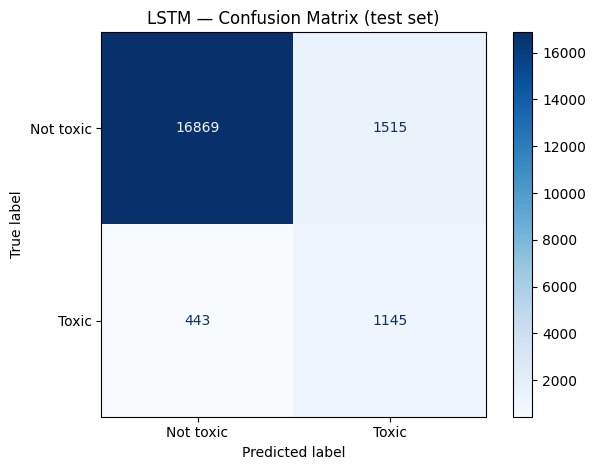

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_arr, y_pred,
    display_labels=["Not toxic", "Toxic"],
    cmap="Blues", values_format="d"
)
plt.title("LSTM — Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig("lstm_confusion_matrix.png", dpi=150)
plt.show()